<a href="https://colab.research.google.com/github/sudikshyapant/sae_probing/blob/main/sae_probing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAE Probing: Athlete Sport Football

Re-implementation of the SAE probing strategy from *Are Sparse Autoencoders Useful? A Case Study in Sparse Probing* (Kantamneni et al., 2025).

**Dataset:** `154_athlete_sport_football` — given an athlete name, classify whether they play football (1) or not (0).

**Pipeline:**
1. Load dataset & split
2. Extract last-token hidden states from Gemma-2-2B at layer 20
3. Encode activations through GemmaScope SAE → sparse latents Z
4. Select top-k SAE features by mean activation difference (k=16, k=128)
5. Train logistic regression probe on Z[:,I_k], select C via val set
6. Evaluate on held-out test set

In [26]:
# !pip install torch transformers sae_lens scikit-learn datasets numpy pandas tqdm huggingface-hub accelerate xgboost

In [ ]:
# Google Drive is mounted automatically when config.py is imported.
# Cache and results dirs are printed below after the main imports cell runs.

In [28]:
import json
import os
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# ── resolve src/ whether running locally or in Colab ─────────────────────────
try:
    _src = Path(__file__).parent / "src"
except NameError:
    _src = Path.cwd() / "src"

if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

# ── project modules ───────────────────────────────────────────────────────────
from config      import CONFIG
from data_utils  import (load_dataset, make_splits,
                          subsample_stratified, make_imbalanced, corrupt_labels)
from model_utils import load_and_cache_activations, load_and_cache_latents
from probes      import (select_top_k_latents, train_sae_probe,
                         probe_p1_logreg, probe_p2_pca, probe_p3_knn,
                         probe_p4_xgboost, probe_p5_mlp)
from quiver      import run_quiver, best_in_quiver, run_all_probes, quiver_table
from plotting    import plot_figure5

print("Device:", CONFIG["device"])
print("src/ loaded from:", _src)

Device: cuda
src/ loaded from: /content/sae_probing/src


In [29]:
# CONFIG is imported from src/config.py — directories are created there.
print("Device     :", CONFIG["device"])
print("Cache dir  :", CONFIG["cache_dir"])
print("Results dir:", CONFIG["results_dir"])

Device     : cuda
Cache dir  : /content/cache
Results dir: /content/result


---
## Step 1 — Load Dataset & Split

- **60% train_pool / 40% test** (stratified on label)
- From train_pool: **80% train / 20% val** (val used only for C selection)

In [30]:
df = load_dataset(CONFIG["data_url"])
print(f"Total examples: {len(df)}")
print(df["target"].value_counts().rename({0: "not football", 1: "football"}))

X_train, X_val, X_test, y_train, y_val, y_test = make_splits(
    df,
    test_size=CONFIG["test_size"],
    val_size=CONFIG["val_size"],
    random_state=CONFIG["random_state"],
)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Total examples: 1772
target
not football    886
football        886
Name: count, dtype: int64
Train: 850, Val: 213, Test: 709


---
## Step 2 — Extract Activations (`X_l`)

Run each prompt through Gemma-2-2B and record the **last-token hidden state** at layer 20.
Cached to `cache/activations.pt` so the model only runs once.

In [33]:
CACHE_ACT = CONFIG["cache_dir"] / "activations.pt"
act_cache = load_and_cache_activations(
    {"train": X_train, "val": X_val, "test": X_test},
    CONFIG,
    CACHE_ACT,
)
X_act_train = act_cache["train"]
X_act_val   = act_cache["val"]
X_act_test  = act_cache["test"]

Loading cached activations…
Loaded. Train shape: (850, 2304)


---
## Step 3 — Encode Through SAE → Latents (`Z`)

**SAELens** is a library that makes it easy to load pre-trained Sparse Autoencoders.
- `sae_release` = the HuggingFace repo name for the SAE collection (`gemma-scope-2b-pt-res-canonical`)
- `sae_id` = the specific SAE within that collection (`layer_20/width_16k`)

The SAE maps each dense activation (dim=2304) to a sparse vector (dim=16,384)

Cached to `cache/latents.pt`.

In [34]:
CACHE_LAT = CONFIG["cache_dir"] / "latents.pt"
lat_cache = load_and_cache_latents(
    {"train": X_act_train, "val": X_act_val, "test": X_act_test},
    CONFIG,
    CACHE_LAT,
)
Z_train = lat_cache["train"]
Z_val   = lat_cache["val"]
Z_test  = lat_cache["test"]

Loading cached SAE latents…
Loaded. Train shape: (850, 16384)


---
## Step 4 — Feature Selection (`I_k`)

For each k in `[16, 128]`, select the top-k SAE latent indices with the largest
mean activation difference between classes (Equation 1 from the paper):

$$\Delta_j = |\bar{Z}_j^{(1)} - \bar{Z}_j^{(0)}|$$

In [35]:
feature_indices = {}
for k in CONFIG["k_values"]:
    feature_indices[k] = select_top_k_latents(Z_train, y_train, k)
    print(f"k={k:4d}: top feature indices (first 5): {feature_indices[k][:5]}")

k=  16: top feature indices (first 5): [10608 13409 12108 10111  8000]
k= 128: top feature indices (first 5): [ 7071  1188  9012 15403 14051]


---
## Step 5 — Train Probe & Evaluate

For each k:
1. Slice latents to `Z[:, I_k]`
2. Grid-search C over `[1e-4 ... 1e4]` using val AUC
3. Report test AUC with best C

In [36]:
C_sae = list(np.logspace(5, -5, 10))

results = {}
for k in CONFIG["k_values"]:
    idx = feature_indices[k]
    res = train_sae_probe(
        Z_train[:, idx], y_train,
        Z_val[:,   idx], y_val,
        Z_test[:,  idx], y_test,
        C_sae,
    )
    results[f"sae_k{k}"] = res
    print(f"k={k:4d} | best C={res['best_hp']['C']:.0e} | val AUC={res['val_auc']:.4f} | test AUC={res['test_auc']:.4f}")

k=  16 | best C=3e-01 | val AUC=0.5648 | test AUC=0.5101
k= 128 | best C=6e+02 | val AUC=0.7361 | test AUC=0.6629


---
## Results

In [37]:
results_path = Path(CONFIG["results_dir"]) / "probe_model.pkl"
with open(results_path, "wb") as f:
    pickle.dump({"config": CONFIG, "results": results, "feature_indices": feature_indices}, f)
print(f"Results saved to {results_path}")

rows = [
    {"Method": m, "Best C": r["best_hp"]["C"], "Val AUC": round(r["val_auc"], 4), "Test AUC": round(r["test_auc"], 4)}
    for m, r in results.items()
]
print(pd.DataFrame(rows).set_index("Method").to_string())

Results saved to /content/result/probe_model.pkl
              Best C  Val AUC  Test AUC
Method                                 
sae_k16     0.278256   0.5648    0.5101
sae_k128  599.484250   0.7361    0.6629


---
## Step 6 — Baseline Probing Methods (p1–p5)

All baselines use **raw activations** `X_act` (not SAE latents).

| ID | Method | HP searched | Scaler |
|----|--------|-------------|--------|
| p1 | Logistic Regression (L2) | C ∈ logspace(5,−5,10) | StandardScaler |
| p2 | PCA + unregularized LogReg | n_components ∈ logspace(0,2,10) | StandardScaler |
| p3 | K-Nearest Neighbours | k ∈ logspace(0,2,10) | StandardScaler |
| p4 | XGBoost | 10-sample random search | none (tree-based) |
| p5 | MLP (sklearn, ReLU + Adam) | 10-sample random search | StandardScaler |

In [38]:
baseline_results = {}  # populated by p1–p5 cells below

C_baseline = list(np.logspace(5, -5, 10))   # paper's C range

res_p1 = probe_p1_logreg(X_act_train, y_train, X_act_val, y_val, X_act_test, y_test, C_baseline)
baseline_results["p1_logreg"] = res_p1
print(f"p1 LogReg L2 | best C={res_p1['best_hp']['C']:.2e} | "
      f"val AUC={res_p1['val_auc']:.4f} | test AUC={res_p1['test_auc']:.4f}")

p1 LogReg L2 | best C=1.67e-03 | val AUC=0.7577 | test AUC=0.7195


In [39]:
res_p2 = probe_p2_pca(X_act_train, y_train, X_act_val, y_val, X_act_test, y_test)
baseline_results["p2_pca"] = res_p2
print(f"p2 PCA+LogReg | best n_components={res_p2['best_hp']['n_components']} | "
      f"val AUC={res_p2['val_auc']:.4f} | test AUC={res_p2['test_auc']:.4f}")

p2 PCA+LogReg | best n_components=59 | val AUC=0.7630 | test AUC=0.7037


In [40]:
res_p3 = probe_p3_knn(X_act_train, y_train, X_act_val, y_val, X_act_test, y_test)
baseline_results["p3_knn"] = res_p3
print(f"p3 KNN | best k={res_p3['best_hp']['k']} | "
      f"val AUC={res_p3['val_auc']:.4f} | test AUC={res_p3['test_auc']:.4f}")

p3 KNN | best k=7 | val AUC=0.6702 | test AUC=0.6646


In [41]:
res_p4 = probe_p4_xgboost(X_act_train, y_train, X_act_val, y_val, X_act_test, y_test)
baseline_results["p4_xgboost"] = res_p4
if res_p4:
    print(f"p4 XGBoost | n_est={res_p4['best_hp']['n_estimators']}, depth={res_p4['best_hp']['max_depth']} | "
          f"val AUC={res_p4['val_auc']:.4f} | test AUC={res_p4['test_auc']:.4f}")

p4 XGBoost | n_est=103, depth=3 | val AUC=0.7547 | test AUC=0.6930


In [42]:
res_p5 = probe_p5_mlp(X_act_train, y_train, X_act_val, y_val, X_act_test, y_test)
baseline_results["p5_mlp"] = res_p5
print(f"p5 MLP | layers={res_p5['best_hp']['hidden']} | "
      f"val AUC={res_p5['val_auc']:.4f} | test AUC={res_p5['test_auc']:.4f}")

p5 MLP | layers=(64, 64, 64) | val AUC=0.7516 | test AUC=0.7319


---
## Quiver Analysis

**Quiver of Arrows** (from the paper): a practitioner runs all methods in their toolkit, picks the best one by **val AUC**, and deploys that probe.

- **Quiver P** — non-SAE toolkit {p1, p2, p3, p4, p5}
- **Quiver P+SAE** — full toolkit {p1, …, p5, sae_k16, sae_k128}

The table below shows each method's individual test AUC, followed by the quiver summary showing which method gets selected (by val AUC) and what test AUC the practitioner ends up with.

In [43]:
# ── Quiver analysis ──────────────────────────────────────────────────────────
all_results = {**baseline_results, **results}   # {p1..p5, sae_k16, sae_k128}

rows = [
    {"Method": m, "Val AUC": round(r["val_auc"], 4), "Test AUC": round(r["test_auc"], 4)}
    for m, r in all_results.items() if r is not None
]
df_all = pd.DataFrame(rows).set_index("Method").sort_values("Val AUC", ascending=False)
print("All methods:\n")
print(df_all.to_string())

# ── Quiver P  (non-SAE toolkit: p1–p5 only)
p_only = {k: v for k, v in all_results.items() if k.startswith("p") and v is not None}
best_p_key, best_p_res = best_in_quiver(p_only)

# ── Quiver P+SAE  (full toolkit including SAE probes) ────────────────────────
valid_all = {k: v for k, v in all_results.items() if v is not None}
best_all_key, best_all_res = best_in_quiver(valid_all)

print("\n" + "─" * 52)
print(f"{'Quiver':<22} {'Best method':<14} {'Val AUC':>8} {'Test AUC':>9}")
print("─" * 52)
print(f"{'P  (no SAE)':<22} {best_p_key:<14} {best_p_res['val_auc']:>8.4f} {best_p_res['test_auc']:>9.4f}")
print(f"{'P + SAE':<22} {best_all_key:<14} {best_all_res['val_auc']:>8.4f} {best_all_res['test_auc']:>9.4f}")
print("─" * 52)

All methods:

            Val AUC  Test AUC
Method                       
p2_pca       0.7630    0.7037
p1_logreg    0.7577    0.7195
p4_xgboost   0.7547    0.6930
p5_mlp       0.7516    0.7319
sae_k128     0.7361    0.6629
p3_knn       0.6702    0.6646
sae_k16      0.5648    0.5101

────────────────────────────────────────────────────
Quiver                 Best method     Val AUC  Test AUC
────────────────────────────────────────────────────
P  (no SAE)            p2_pca           0.7630    0.7037
P + SAE                p2_pca           0.7630    0.7037
────────────────────────────────────────────────────


In [50]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

---
## Section 7 — Regime Experiments (Figure 5 Replication)

Following Section 3.2 of the paper, we vary three data conditions on the `154_athlete_sport_football` dataset and compare:
- **Non-SAE quiver**: best of {LogReg L2, PCA+LogReg, KNN} by val AUC
- **SAE quiver**: best of {LogReg L2, PCA+LogReg, KNN, SAE probe k=128} by val AUC

**Regimes:**
1. **Data Scarcity** — 20 log-spaced values of n in [2, max_train]
2. **Class Imbalance** — 19 linear values of ratio = n₁/n in [0.05, 0.95], same ratio applied to test set
3. **Label Noise** — 11 linear values of corruption fraction in [0.0, 0.5]; compare LR vs SAE head-to-head (paper's method)

In [44]:
# ── Regime experiment setup ────────────────────────────────────────────────────
# Helper functions imported from src/:
#   data_utils : subsample_stratified, make_imbalanced, corrupt_labels
#   quiver     : run_quiver, run_all_probes, quiver_table

import warnings
warnings.filterwarnings("ignore")

np.random.seed(CONFIG["random_state"])

C_REGIME = list(np.logspace(5, -5, 10))   # paper's C range for all probes

CACHE_REGIMES = CONFIG["cache_dir"] / "regime_results.pt"
_regime_cache = (
    torch.load(CACHE_REGIMES, weights_only=False)
    if CACHE_REGIMES.exists() else {}
)
print(f"Cached regimes: {list(_regime_cache.keys()) or 'none'}")
print("Regime setup done.")

Cached regimes: none
Regime setup done.


In [45]:
# ── Regime 1: Data Scarcity ───────────────────────────────────────────────────
if "scarcity" in _regime_cache:
    print("Loading scarcity results from cache…")
    _sc             = _regime_cache["scarcity"]
    n_values        = _sc["n_values"]
    scarcity_no_sae = list(_sc["no_sae"])
    scarcity_sae    = list(_sc["sae"])
    print(f"  Loaded {len(n_values)} n values.")
else:
    _n_max   = len(X_act_train)
    n_values = np.unique(np.logspace(np.log10(2), np.log10(_n_max), 20).astype(int))
    scarcity_no_sae, scarcity_sae = [], []

    for n in tqdm(n_values, desc="Data scarcity"):
        X_tr_n, Z_tr_n, y_tr_n = subsample_stratified(X_act_train, Z_train, y_train, n)
        no_sae, with_sae = run_quiver(
            X_tr_n, y_tr_n, Z_tr_n,
            X_act_val, y_val, Z_val,
            X_act_test, y_test, Z_test,
            C_REGIME, include_sae=True, sae_k=128,
        )
        scarcity_no_sae.append(no_sae)
        scarcity_sae.append(with_sae)

    _regime_cache["scarcity"] = {
        "n_values": n_values, "no_sae": scarcity_no_sae, "sae": scarcity_sae,
    }
    torch.save(_regime_cache, CACHE_REGIMES)
    print("Data scarcity done — cached.")

print(f"  n values : {n_values.tolist()}")
print(f"  No-SAE   : {[round(v, 3) for v in scarcity_no_sae]}")
print(f"  With-SAE : {[round(v, 3) for v in scarcity_sae]}")

Data scarcity:   0%|          | 0/19 [00:00<?, ?it/s]

Data scarcity done — cached.
  n values : [2, 3, 5, 7, 9, 13, 18, 25, 35, 48, 66, 91, 125, 172, 237, 326, 449, 618, 850]
  No-SAE   : [0.515, 0.523, 0.498, 0.529, 0.524, 0.551, 0.545, 0.583, 0.592, 0.596, 0.64, 0.677, 0.683, 0.68, 0.667, 0.697, 0.675, 0.709, 0.72]
  With-SAE : [0.529, 0.513, 0.52, 0.528, 0.524, 0.658, 0.526, 0.661, 0.592, 0.657, 0.65, 0.677, 0.656, 0.659, 0.664, 0.697, 0.675, 0.709, 0.72]


In [46]:
# ── Regime 2: Class Imbalance ─────────────────────────────────────────────────
if "imbalance" in _regime_cache:
    print("Loading imbalance results from cache…")
    _im              = _regime_cache["imbalance"]
    ratio_values     = _im["ratio_values"]
    imbalance_no_sae = list(_im["no_sae"])
    imbalance_sae    = list(_im["sae"])
    print(f"  Loaded {len(ratio_values)} ratio values.")
else:
    ratio_values     = np.linspace(0.05, 0.95, 19)
    imbalance_no_sae, imbalance_sae = [], []

    for ratio in tqdm(ratio_values, desc="Class imbalance"):
        X_tr_r, Z_tr_r, y_tr_r = make_imbalanced(X_act_train, Z_train, y_train, ratio)
        X_te_r, Z_te_r, y_te_r = make_imbalanced(X_act_test,  Z_test,  y_test,  ratio)

        if (len(y_tr_r) < 2 or len(np.unique(y_tr_r)) < 2
                or len(y_te_r) < 2 or len(np.unique(y_te_r)) < 2):
            imbalance_no_sae.append(np.nan)
            imbalance_sae.append(np.nan)
            continue

        no_sae, with_sae = run_quiver(
            X_tr_r, y_tr_r, Z_tr_r,
            X_act_val, y_val, Z_val,
            X_te_r, y_te_r, Z_te_r,
            C_REGIME, include_sae=True, sae_k=128,
        )
        imbalance_no_sae.append(no_sae)
        imbalance_sae.append(with_sae)

    _regime_cache["imbalance"] = {
        "ratio_values": ratio_values, "no_sae": imbalance_no_sae, "sae": imbalance_sae,
    }
    torch.save(_regime_cache, CACHE_REGIMES)
    print("Class imbalance done — cached.")

print(f"  ratios   : {np.round(ratio_values, 2).tolist()}")
print(f"  No-SAE   : {[round(v, 3) if not np.isnan(v) else 'nan' for v in imbalance_no_sae]}")
print(f"  With-SAE : {[round(v, 3) if not np.isnan(v) else 'nan' for v in imbalance_sae]}")

Class imbalance:   0%|          | 0/19 [00:00<?, ?it/s]

Class imbalance done — cached.
  ratios   : [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
  No-SAE   : [0.657, 0.69, 0.667, 0.672, 0.695, 0.656, 0.692, 0.704, 0.714, 0.706, 0.711, 0.684, 0.687, 0.663, 0.68, 0.706, 0.708, 0.651, 0.791]
  With-SAE : [0.658, 0.69, 0.63, 0.672, 0.695, 0.656, 0.692, 0.704, 0.714, 0.706, 0.711, 0.684, 0.687, 0.663, 0.68, 0.706, 0.708, 0.649, 0.791]


In [47]:
# ── Regime 3: Label Noise ─────────────────────────────────────────────────────
if "noise" in _regime_cache:
    print("Loading noise results from cache…")
    _ns             = _regime_cache["noise"]
    fraction_values = _ns["fraction_values"]
    noise_logreg    = list(_ns["logreg"])
    noise_sae       = list(_ns["sae"])
    print(f"  Loaded {len(fraction_values)} fraction values.")
else:
    fraction_values = np.linspace(0.0, 0.5, 11)
    noise_logreg, noise_sae = [], []

    for frac in tqdm(fraction_values, desc="Label noise"):
        y_tr_noisy = corrupt_labels(y_train, frac)

        res_lr = probe_p1_logreg(
            X_act_train, y_tr_noisy,
            X_act_val,   y_val,
            X_act_test,  y_test,
            C_REGIME,
        )
        feat_idx_noise = select_top_k_latents(Z_train, y_tr_noisy, 128)
        res_sae = train_sae_probe(
            Z_train[:, feat_idx_noise], y_tr_noisy,
            Z_val[:,   feat_idx_noise], y_val,
            Z_test[:,  feat_idx_noise], y_test,
            C_REGIME,
        )
        noise_logreg.append(res_lr["test_auc"])
        noise_sae.append(res_sae["test_auc"])

    _regime_cache["noise"] = {
        "fraction_values": fraction_values, "logreg": noise_logreg, "sae": noise_sae,
    }
    torch.save(_regime_cache, CACHE_REGIMES)
    print("Label noise done — cached.")

print(f"  fractions : {np.round(fraction_values, 2).tolist()}")
print(f"  LogReg    : {[round(v, 3) for v in noise_logreg]}")
print(f"  SAE k=128 : {[round(v, 3) for v in noise_sae]}")

Label noise:   0%|          | 0/11 [00:00<?, ?it/s]

Label noise done — cached.
  fractions : [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
  LogReg    : [0.72, 0.718, 0.704, 0.694, 0.689, 0.66, 0.623, 0.595, 0.554, 0.536, 0.515]
  SAE k=128 : [0.663, 0.55, 0.535, 0.576, 0.55, 0.525, 0.519, 0.556, 0.529, 0.519, 0.499]


In [48]:
# ── Save regime results to results/ ───────────────────────────────────────────
def _to_json(v):
    """Convert numpy arrays / lists of floats to JSON-serialisable form."""
    if hasattr(v, "tolist"):
        return v.tolist()
    return [None if (isinstance(x, float) and np.isnan(x)) else float(x) for x in v]

regime_summary = {
    "scarcity": {
        "n_values":   _to_json(n_values),
        "no_sae_auc": _to_json(scarcity_no_sae),
        "sae_auc":    _to_json(scarcity_sae),
    },
    "imbalance": {
        "ratio_values": _to_json(ratio_values),
        "no_sae_auc":   _to_json(imbalance_no_sae),
        "sae_auc":      _to_json(imbalance_sae),
    },
    "noise": {
        "fraction_values": _to_json(fraction_values),
        "logreg_auc":      _to_json(noise_logreg),
        "sae_auc":         _to_json(noise_sae),
    },
}

results_json = CONFIG["results_dir"] / "regime_results.json"
with open(results_json, "w") as f:
    json.dump(regime_summary, f, indent=2)
print(f"Regime results saved to {results_json}")

Regime results saved to /content/result/regime_results.json


Figure saved to /content/result/figure5_regimes.png


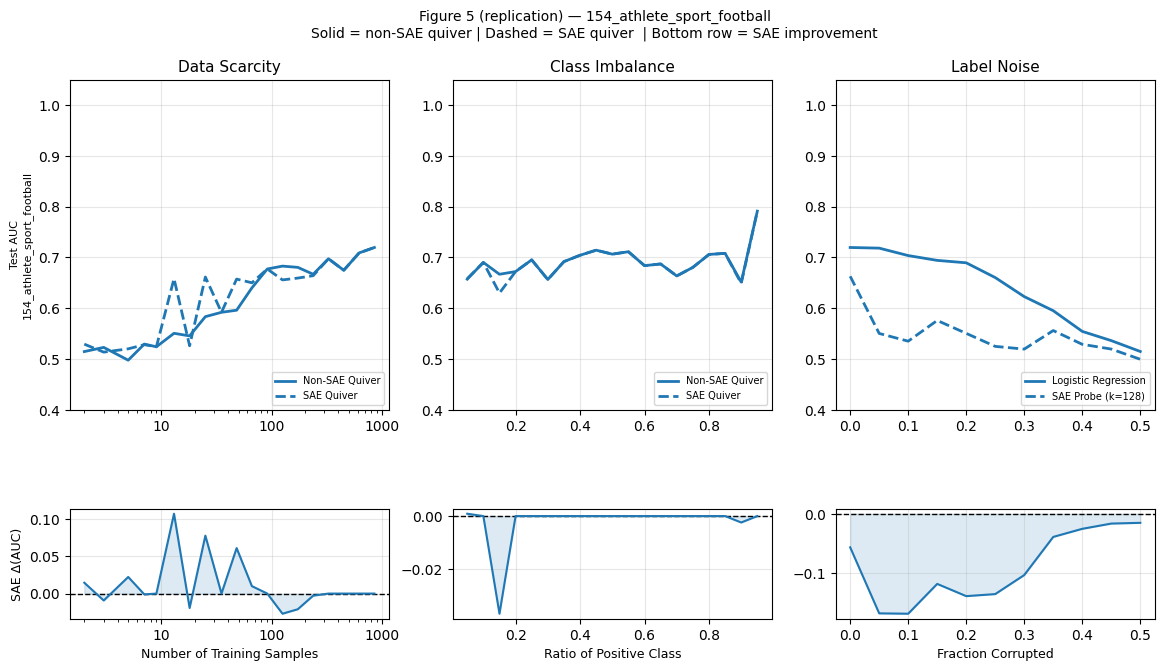

In [49]:
# ── Figure 5 (replication for 154_athlete_sport_football) ─────────────────────
import matplotlib.pyplot as plt

fig = plot_figure5(
    n_values,        scarcity_no_sae,  scarcity_sae,
    ratio_values,    imbalance_no_sae, imbalance_sae,
    fraction_values, noise_logreg,     noise_sae,
    dataset_name="154_athlete_sport_football",
    color="#1f77b4",
    save_path=CONFIG["results_dir"] / "figure5_regimes.png",
)
plt.show()